# chuq_split — reaction cross section vs energy, low (surface) vs high (volume)

Run **after** both dynesty jobs finish. Both calibrations are fits to elastic `dXS/dRuth` only. 
This notebook computes $\sigma_{\rm rxn}(E)$ for p + Ca-40 over `[0.01, 200]` MeV under each posterior, 
with 68% / 95% bands.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import chuq_io
import chuq_model

chuq_io.use_paper_style()

# Raises a message pointing at build_configs.py + the sampling jobs if the calibration has not
# been run in this checkout, rather than a bare FileNotFoundError.
fit_info = chuq_io.load_fit_info()
e_split_low, e_split_high = fit_info["E0"], fit_info["E1"]
posterior_samples = chuq_io.load_all_posteriors()

# The energy span of the data each model actually saw. Shading the *data* span rather than the
# nominal band ([0, E0] and (E1, 200]) is deliberate: a stretch of a band with no data in it is
# not a training region. Derived from the same split the fits used, never hardcoded.
datasets = chuq_io.load_datasets()
bands = chuq_io.split_bands(datasets, e_split_low, e_split_high)
band_span = {
    band: (min(chuq_io.elab(d) for d in sets), max(chuq_io.elab(d) for d in sets))
    for band, sets in bands.items()
}
for band in chuq_io.BAND_NAMES:
    lo, hi = band_span[band]
    print(f"{band:>5}: {len(bands[band]):2d} datasets, E_lab {lo:6.2f} - {hi:6.2f} MeV")

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31
  low: 25 datasets, E_lab   5.40 -  19.57 MeV
 test: 13 datasets, E_lab  20.57 -  40.00 MeV
 high: 13 datasets, E_lab  45.00 - 201.40 MeV


## $\sigma_{\rm rxn}$ under each posterior

In [2]:
# --- settings ------------------------------------------------------------------------------
N_XS_DRAWS = 200        # posterior draws per variant; the 16/84 band is stable well below this
XS_DRAW_SEED = 4        # seeds 0-3 are taken by the other notebooks
E_MIN_MEV, E_MAX_MEV = 0.01, 200.0
N_ENERGY = 60
# Log-spaced: the range covers 4.3 decades, and everything interesting happens in the top one.
E_GRID_MEV = np.geomspace(E_MIN_MEV, E_MAX_MEV, N_ENERGY)
BAND_QUANTILES = (2.5, 16, 50, 84, 97.5)  # same levels as chuq_coverage.ipynb

rng = np.random.default_rng(XS_DRAW_SEED)
draws = {
    v: posterior_samples[v][
        rng.choice(len(posterior_samples[v]), N_XS_DRAWS, replace=False),
        : chuq_model.n_omp(v),
    ]
    for v in chuq_io.VARIANT_NAMES
}

sigma_rxn = {v: np.full((N_XS_DRAWS, N_ENERGY), np.nan) for v in chuq_io.VARIANT_NAMES}
n_failed = 0
for j, e_lab in enumerate(E_GRID_MEV):
    # Independent of the variant and of the parameters, so one build serves both models and
    # every draw at this energy. This hoist is what makes the sweep ~10 min instead of hours.
    workspace = chuq_model.integral_workspace(e_lab)
    for variant in chuq_io.VARIANT_NAMES:
        for i, theta_omp in enumerate(draws[variant]):
            try:
                sigma_rxn[variant][i, j] = chuq_model.reaction_cross_section(
                    theta_omp, workspace, variant
                )
            except Exception:
                # One pathological draw at one energy must not cost the whole sweep. It stays
                # NaN, drops out of the nan-aware quantiles below, and is counted here.
                n_failed += 1

print(f"{n_failed} of {2 * N_XS_DRAWS * N_ENERGY} solves failed")

# Rows are BAND_QUANTILES in order: 2.5, 16, 50, 84, 97.5.
quantiles = {
    v: np.nanpercentile(sigma_rxn[v], BAND_QUANTILES, axis=0)
    for v in chuq_io.VARIANT_NAMES
}

0 of 24000 solves failed


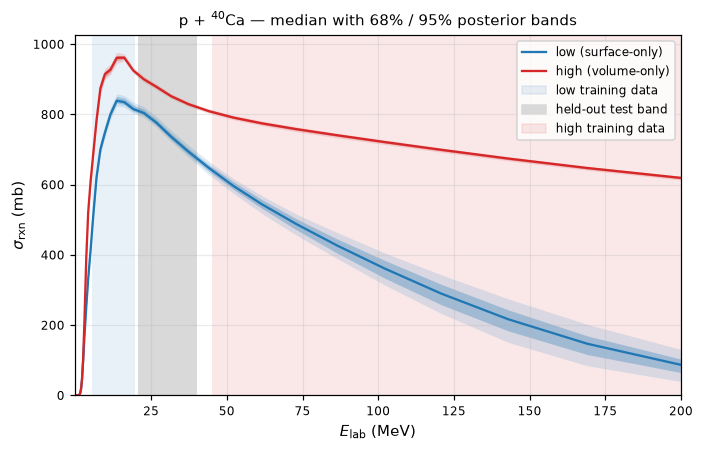

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))

# Each model's training region in its own colour, plus the held-out band in the same grey the
# other notebooks use for it. Kept faint: this is context for the curves, not the subject. The
# three spans tile 5.4-201 MeV; outside them both models are extrapolating.
for variant in chuq_io.VARIANT_NAMES:
    ax.axvspan(
        *band_span[variant],
        color=chuq_io.VARIANT_COLOR[variant],
        alpha=0.10,
        lw=0,
        zorder=0,
    )
ax.axvspan(*band_span["test"], color="0.85", lw=0, zorder=0)

for variant in chuq_io.VARIANT_NAMES:
    color = chuq_io.VARIANT_COLOR[variant]
    # Clip the sub-barrier roundoff-negatives (order 1e-12 mb) to zero so the curves sit exactly
    # on the axis there instead of dipping below it.
    lo95, lo68, median, hi68, hi95 = np.clip(quantiles[variant], 0.0, None)
    ax.fill_between(E_GRID_MEV, lo95, hi95, color=color, alpha=0.15, lw=0)
    ax.fill_between(E_GRID_MEV, lo68, hi68, color=color, alpha=0.30, lw=0)
    ax.plot(
        E_GRID_MEV,
        median,
        color=color,
        label=f"{variant} ({chuq_io.VARIANT_FORM[variant]})",
    )

ax.set_xlim(E_MIN_MEV, E_MAX_MEV)
ax.set_ylim(bottom=0.0)
ax.set_xlabel(r"$E_{\rm lab}$ (MeV)")
ax.set_ylabel(r"$\sigma_{\rm rxn}$ (mb)")
ax.set_title(r"p + $^{40}$Ca — median with 68% / 95% posterior bands")

# Proxy handles: the shaded spans carry meaning and would otherwise go unlabelled.
shading = [
    Patch(color=chuq_io.VARIANT_COLOR["low"], alpha=0.10, label="low training data"),
    Patch(color="0.85", label="held-out test band"),
    Patch(color=chuq_io.VARIANT_COLOR["high"], alpha=0.10, label="high training data"),
]
# Upper left: on a linear ordinate the sub-barrier decades are flat at zero, so that corner is
# the only empty one.
ax.legend(handles=ax.get_legend_handles_labels()[0] + shading, loc="upper right")
fig.tight_layout()
chuq_io.save_figure(fig, "reaction_xs_vs_energy")
plt.show()